# 23.1 - Understanding Surrounding Tissue Normalization

This notebook explains the concepts behind NB 23:
- **Why normalize?** Remove machine/gain variability so features reflect tissue properties
- **Z-score normalization**: what it does mathematically and to the image
- **The mask dilation trick**: creating a surrounding tissue ring
- **The redundancy insight**: why texture features are (mostly) invariant to linear transforms
- **Contrast features**: the genuinely novel information (pancreas vs surrounding)

Uses toy examples and one real ultrasound image to build intuition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import pydicom
from scipy import stats

np.set_printoptions(precision=3, suppress=True)
print("Imports OK")

Imports OK


## The problem: gain variability

Ultrasound images of the same tissue can look very different depending on machine
settings (gain, time-gain compensation, probe pressure). Two images of identical
tissue can have completely different intensity histograms, making raw features
unreliable for cross-image comparison.

Here we simulate this with a toy tissue pattern at two different "gain" settings.

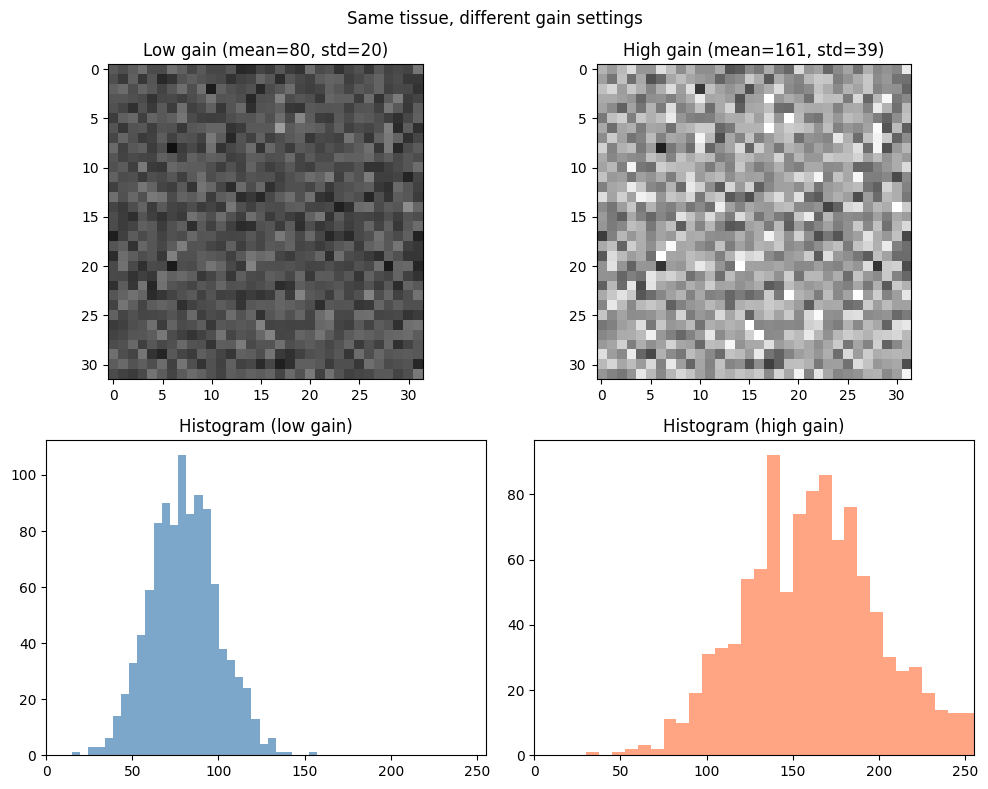

Problem: raw features (mean, std, percentiles) differ despite identical tissue.
  Low gain:  mean=80.1, std=19.6
  High gain: mean=160.5, std=38.8


In [2]:
np.random.seed(42)
size = 32

# Create a "tissue" pattern (same underlying structure)
tissue = np.random.normal(loc=0, scale=1, size=(size, size))

# Simulate two different gain settings
gain_low = (tissue * 20 + 80).clip(0, 255).astype(np.uint8)    # mean~80, std~20
gain_high = (tissue * 40 + 160).clip(0, 255).astype(np.uint8)  # mean~160, std~40

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(gain_low, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title(f"Low gain (mean={gain_low.mean():.0f}, std={gain_low.std():.0f})")

axes[0, 1].imshow(gain_high, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title(f"High gain (mean={gain_high.mean():.0f}, std={gain_high.std():.0f})")

axes[1, 0].hist(gain_low.flatten(), bins=30, color="steelblue", alpha=0.7)
axes[1, 0].set_title("Histogram (low gain)")
axes[1, 0].set_xlim(0, 255)

axes[1, 1].hist(gain_high.flatten(), bins=30, color="coral", alpha=0.7)
axes[1, 1].set_title("Histogram (high gain)")
axes[1, 1].set_xlim(0, 255)

plt.suptitle("Same tissue, different gain settings", fontsize=12)
plt.tight_layout()
plt.show()

print("Problem: raw features (mean, std, percentiles) differ despite identical tissue.")
print(f"  Low gain:  mean={gain_low.mean():.1f}, std={gain_low.std():.1f}")
print(f"  High gain: mean={gain_high.mean():.1f}, std={gain_high.std():.1f}")

## Z-score normalization

The idea: express each pixel's intensity relative to the local context:

$$z = \frac{x - \mu_{surrounding}}{\sigma_{surrounding}}$$

After normalization:
- A pixel with z = 0 is average (same intensity as surrounding)
- A pixel with z = +2 is 2 standard deviations brighter than surrounding
- A pixel with z = -1 is 1 standard deviation darker than surrounding

This removes the effect of gain: if everything gets brighter, the z-scores stay the same.

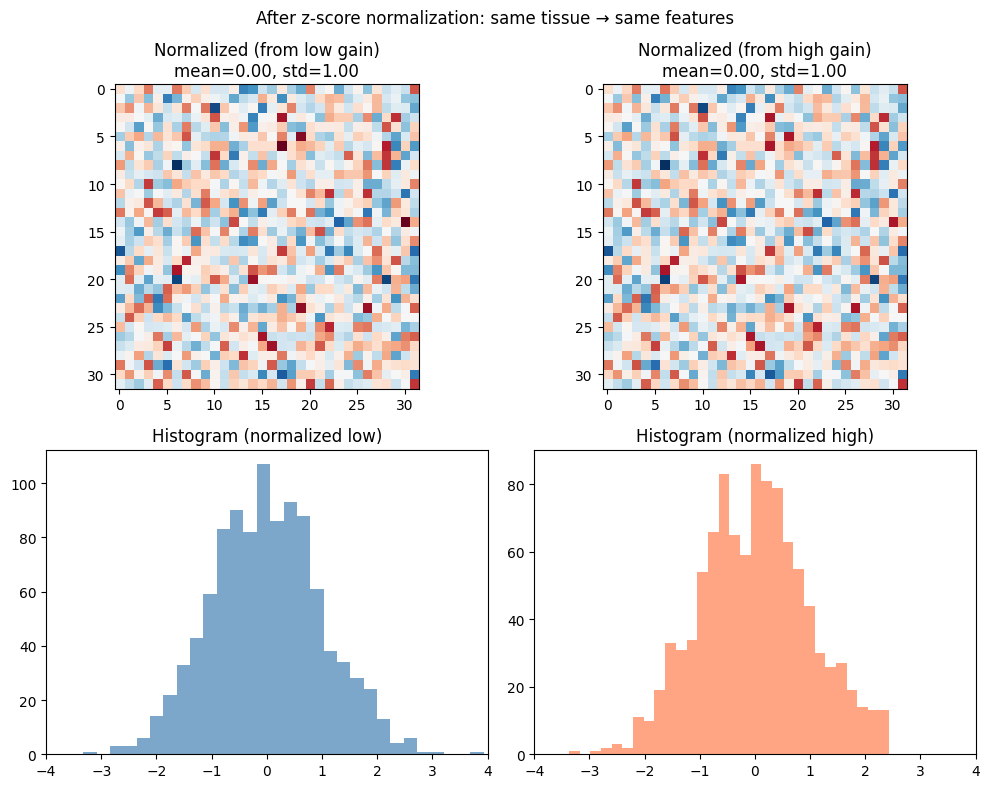

Spearman correlation between the two normalized images: 0.9999
They are now virtually identical (same tissue → same normalized representation).


In [3]:
# Apply z-score normalization using the image's own stats as surrogate for surrounding
def normalize_zscore(img):
    mu = img.mean()
    sigma = img.std()
    return (img.astype(np.float64) - mu) / sigma

norm_low = normalize_zscore(gain_low)
norm_high = normalize_zscore(gain_high)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(norm_low, cmap="RdBu_r", vmin=-3, vmax=3)
axes[0, 0].set_title(f"Normalized (from low gain)\nmean={norm_low.mean():.2f}, std={norm_low.std():.2f}")

axes[0, 1].imshow(norm_high, cmap="RdBu_r", vmin=-3, vmax=3)
axes[0, 1].set_title(f"Normalized (from high gain)\nmean={norm_high.mean():.2f}, std={norm_high.std():.2f}")

axes[1, 0].hist(norm_low.flatten(), bins=30, color="steelblue", alpha=0.7)
axes[1, 0].set_title("Histogram (normalized low)")
axes[1, 0].set_xlim(-4, 4)

axes[1, 1].hist(norm_high.flatten(), bins=30, color="coral", alpha=0.7)
axes[1, 1].set_title("Histogram (normalized high)")
axes[1, 1].set_xlim(-4, 4)

plt.suptitle("After z-score normalization: same tissue → same features", fontsize=12)
plt.tight_layout()
plt.show()

# Correlation between normalized versions
rho, _ = stats.spearmanr(norm_low.flatten(), norm_high.flatten())
print(f"Spearman correlation between the two normalized images: {rho:.4f}")
print("They are now virtually identical (same tissue → same normalized representation).")

## The surrounding tissue mask

In NB 23, we don't use the whole image for normalization. Instead, we use only the
tissue immediately surrounding the pancreas — the "ring" created by:

1. **Dilate** the pancreas mask by N pixels (elliptical structuring element)
2. **Subtract** the original mask → gives a ring
3. **Exclude** black pixels (outside ultrasound cone)

This is better than using the whole image because:
- The surrounding tissue is at a similar depth (similar TGC effect)
- It excludes distant structures that may have different gain
- It provides a local reference for the pancreas specifically

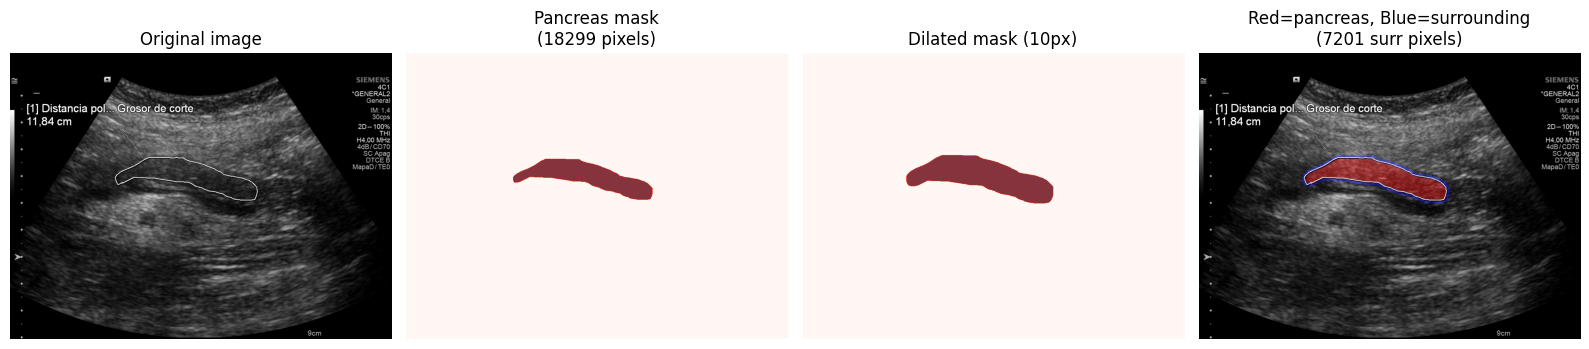

Pancreas pixels: 18299
Surrounding pixels: 7201
Ratio (surrounding/pancreas): 0.39


In [4]:
# Demonstrate mask dilation on a real image
raw_folder = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2")
mask_folder = os.path.join("..", "data", "PANCREAS_PREPROCESSED_CONTOUR_SUBTRACTED_ERODED_K3_I1", "masks")

study_id = "01_01"
patient_folder = os.path.join(raw_folder, study_id)
subfolders = [f for f in os.listdir(patient_folder) if not f.startswith(".")]
date_folder = os.path.join(patient_folder, subfolders[0])
files = [f for f in os.listdir(date_folder) if not f.startswith(".")]
ds = pydicom.dcmread(os.path.join(date_folder, files[0]))
pixels = ds.pixel_array
if len(pixels.shape) == 3:
    gray = cv2.cvtColor(pixels, cv2.COLOR_RGB2GRAY)
else:
    gray = pixels

mask_path = os.path.join(mask_folder, f"{study_id}_mask_eroded_k3_i1.png")
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask = (mask > 0).astype(np.uint8)
if gray.shape != mask.shape:
    mask = cv2.resize(mask, (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_NEAREST)

# Create surrounding mask
dilation_px = 10
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*dilation_px+1, 2*dilation_px+1))
dilated = cv2.dilate(mask, kernel, iterations=1)
surrounding = dilated - mask
surrounding[gray == 0] = 0  # exclude black regions

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="Reds", alpha=0.8)
axes[1].set_title(f"Pancreas mask\n({mask.sum()} pixels)")
axes[1].axis("off")

axes[2].imshow(dilated, cmap="Reds", alpha=0.8)
axes[2].set_title("Dilated mask (10px)")
axes[2].axis("off")

# Combined view
overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
overlay[mask > 0, 0] = np.minimum(overlay[mask > 0, 0].astype(int) + 100, 255).astype(np.uint8)
overlay[surrounding > 0, 2] = np.minimum(overlay[surrounding > 0, 2].astype(int) + 100, 255).astype(np.uint8)
axes[3].imshow(overlay)
axes[3].set_title(f"Red=pancreas, Blue=surrounding\n({surrounding.sum()} surr pixels)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print(f"Pancreas pixels: {mask.sum()}")
print(f"Surrounding pixels: {surrounding.sum()}")
print(f"Ratio (surrounding/pancreas): {surrounding.sum()/mask.sum():.2f}")

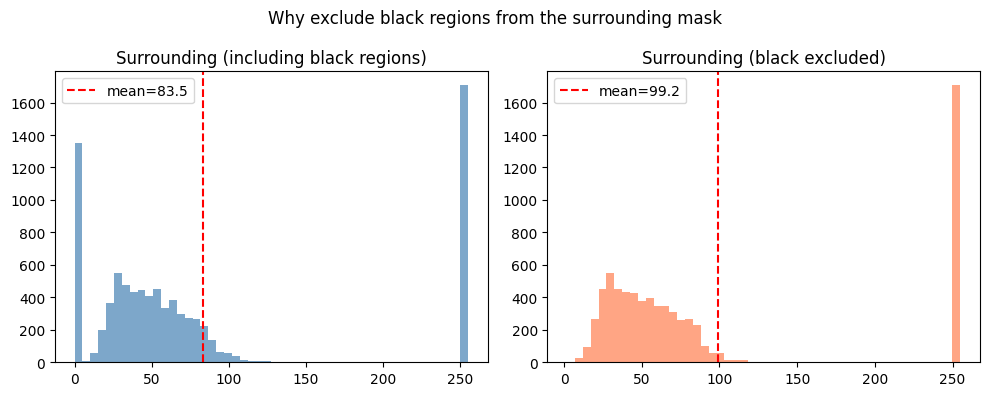

With black:    mean=83.5, std=89.3
Without black: mean=99.2, std=88.9

Including black pixels (value=0) artificially lowers the mean and
inflates the std, making normalization unreliable.


In [5]:
# Why exclude black regions?
surrounding_with_black = dilated - mask  # WITHOUT excluding black
surrounding_no_black = surrounding.copy()  # WITH exclusion

vals_with = gray[surrounding_with_black > 0].astype(np.float64)
vals_without = gray[surrounding_no_black > 0].astype(np.float64)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(vals_with, bins=50, color="steelblue", alpha=0.7)
axes[0].axvline(vals_with.mean(), color="red", linestyle="--", label=f"mean={vals_with.mean():.1f}")
axes[0].set_title("Surrounding (including black regions)")
axes[0].legend()

axes[1].hist(vals_without, bins=50, color="coral", alpha=0.7)
axes[1].axvline(vals_without.mean(), color="red", linestyle="--", label=f"mean={vals_without.mean():.1f}")
axes[1].set_title("Surrounding (black excluded)")
axes[1].legend()

plt.suptitle("Why exclude black regions from the surrounding mask", fontsize=12)
plt.tight_layout()
plt.show()

print(f"With black:    mean={vals_with.mean():.1f}, std={vals_with.std():.1f}")
print(f"Without black: mean={vals_without.mean():.1f}, std={vals_without.std():.1f}")
print("\nIncluding black pixels (value=0) artificially lowers the mean and")
print("inflates the std, making normalization unreliable.")

## The redundancy insight: texture features and linear transforms

Here's the key insight that NB 23 revealed:

**Texture features based on pixel orderings are invariant to monotonic transforms.**

Many PyRadiomics features (GLCM, GLRLM, GLSZM, GLDM, NGTDM) work by:
1. Binning pixel values into discrete gray levels
2. Computing co-occurrence or run-length matrices from the binned image
3. Extracting statistics from these matrices

Z-score normalization `(x - mu) / sigma` is a **linear transform**. If we then re-bin
the result, the binning order is preserved (no pixel that was darker becomes brighter
relative to another pixel). Therefore, the texture matrices are identical, and texture
features are unchanged.

However, **first-order features** (Mean, Median, percentiles) and **gray-level-emphasis
features** (LowGrayLevelEmphasis, HighGrayLevelEmphasis) DO change, because they
depend on absolute gray level values, not just orderings.

Let's verify with a small example.

In [6]:
# Demonstrate with a tiny 4x4 matrix
original = np.array([
    [10, 20, 30, 40],
    [20, 50, 60, 30],
    [30, 60, 80, 50],
    [40, 30, 50, 20],
], dtype=np.float64)

# Z-score normalize
mu = original.mean()
sigma = original.std()
normalized = (original - mu) / sigma

print("Original matrix:")
print(original)
print(f"\nMean={mu:.1f}, Std={sigma:.1f}")

print(f"\nNormalized matrix (z-scores):")
print(normalized)

# Show that rank order is preserved
orig_ranks = stats.rankdata(original.flatten())
norm_ranks = stats.rankdata(normalized.flatten())
print(f"\nOriginal ranks: {orig_ranks}")
print(f"Normalized ranks: {norm_ranks}")
print(f"Ranks identical? {np.array_equal(orig_ranks, norm_ranks)}")
print("\n→ Any feature based on rank/ordering is unchanged by normalization.")

Original matrix:
[[10. 20. 30. 40.]
 [20. 50. 60. 30.]
 [30. 60. 80. 50.]
 [40. 30. 50. 20.]]

Mean=38.8, Std=18.0

Normalized matrix (z-scores):
[[-1.599 -1.043 -0.487  0.07 ]
 [-1.043  0.626  1.182 -0.487]
 [-0.487  1.182  2.294  0.626]
 [ 0.07  -0.487  0.626 -1.043]]

Original ranks: [ 1.   3.   6.5  9.5  3.  12.  14.5  6.5  6.5 14.5 16.  12.   9.5  6.5
 12.   3. ]
Normalized ranks: [ 1.   3.   6.5  9.5  3.  12.  14.5  6.5  6.5 14.5 16.  12.   9.5  6.5
 12.   3. ]
Ranks identical? True

→ Any feature based on rank/ordering is unchanged by normalization.


In [7]:
# GLCM is invariant to linear transform (after re-binning)
# Simple demonstration: compute co-occurrence manually

def compute_simple_cooccurrence(matrix, n_levels=4):
    """Compute horizontal co-occurrence matrix (d=1, theta=0)."""
    # Bin to n_levels
    flat = matrix.flatten()
    edges = np.linspace(flat.min(), flat.max() + 1e-10, n_levels + 1)
    binned = np.digitize(flat, edges) - 1
    binned = binned.reshape(matrix.shape)
    binned = np.clip(binned, 0, n_levels - 1)

    # Compute co-occurrence (horizontal neighbours)
    glcm = np.zeros((n_levels, n_levels), dtype=int)
    rows, cols = matrix.shape
    for r in range(rows):
        for c in range(cols - 1):
            i = binned[r, c]
            j = binned[r, c + 1]
            glcm[i, j] += 1
            glcm[j, i] += 1  # symmetric
    return glcm, binned


glcm_orig, binned_orig = compute_simple_cooccurrence(original)
glcm_norm, binned_norm = compute_simple_cooccurrence(normalized)

print("Binned original:")
print(binned_orig)
print("\nBinned normalized:")
print(binned_norm)

print("\nGLCM from original:")
print(glcm_orig)
print("\nGLCM from normalized:")
print(glcm_norm)

print(f"\nGLCMs identical? {np.array_equal(glcm_orig, glcm_norm)}")
print("\n→ The co-occurrence structure is preserved by linear transforms.")
print("  Any feature computed from GLCM (contrast, correlation, entropy, etc.)")
print("  will be the same for original and normalized images.")

Binned original:
[[0 0 1 1]
 [0 2 2 1]
 [1 2 3 2]
 [1 1 2 0]]

Binned normalized:
[[0 0 1 1]
 [0 2 2 1]
 [1 2 3 2]
 [1 1 2 0]]

GLCM from original:
[[2 1 2 0]
 [1 4 3 0]
 [2 3 2 2]
 [0 0 2 0]]

GLCM from normalized:
[[2 1 2 0]
 [1 4 3 0]
 [2 3 2 2]
 [0 0 2 0]]

GLCMs identical? True

→ The co-occurrence structure is preserved by linear transforms.
  Any feature computed from GLCM (contrast, correlation, entropy, etc.)
  will be the same for original and normalized images.


## What DOES change with normalization?

Two categories of features are affected:

1. **First-order features** (Mean, Median, percentiles, RMS): these directly measure
   intensity values, so shifting/scaling the image changes them.

2. **Gray-level emphasis features** (LowGrayLevelEmphasis, HighGrayLevelEmphasis):
   these weight runs/zones by their gray level. If normalization shifts what
   counts as "low" or "high" gray level, these features change.

In NB 23, we found median Spearman ρ = 0.83 between normalized and original features.
Pure ordinal features had ρ > 0.99, while first-order features had ρ < 0.2.

In [8]:
# Show which features change
# Simulate with the real image
pancreas_vals = gray[mask > 0].astype(np.float64)
surround_vals = gray[surrounding > 0].astype(np.float64)

surr_mean = surround_vals.mean()
surr_std = surround_vals.std()

# Normalized pancreas values
pancreas_normalized = (pancreas_vals - surr_mean) / surr_std

print("First-order features that CHANGE with normalization:")
print(f"  Original mean:     {pancreas_vals.mean():.2f}")
print(f"  Normalized mean:   {pancreas_normalized.mean():.2f}")
print(f"  Original median:   {np.median(pancreas_vals):.2f}")
print(f"  Normalized median: {np.median(pancreas_normalized):.2f}")
print(f"  Original std:      {pancreas_vals.std():.2f}")
print(f"  Normalized std:    {pancreas_normalized.std():.2f}")
print()
print("Features that are PRESERVED (rank-based):")
rho, _ = stats.spearmanr(pancreas_vals, pancreas_normalized)
print(f"  Spearman correlation (original vs normalized values): {rho:.6f}")
print(f"  → Rank order is perfectly preserved (rho=1.0), so GLCM/GLRLM")
print(f"    computed after re-binning will be identical.")

First-order features that CHANGE with normalization:
  Original mean:     44.46
  Normalized mean:   -0.62
  Original median:   43.00
  Normalized median: -0.63
  Original std:      15.11
  Normalized std:    0.17

Features that are PRESERVED (rank-based):
  Spearman correlation (original vs normalized values): 1.000000
  → Rank order is perfectly preserved (rho=1.0), so GLCM/GLRLM
    computed after re-binning will be identical.


## Contrast features: the novel contribution

Instead of normalizing then re-extracting the same features (which are mostly redundant),
a more informative approach is to **directly compare** the pancreas to its surroundings:

- **Mean difference**: Is the pancreas brighter or darker than surrounding?
- **Mean ratio**: By what factor?
- **Std difference**: Is the pancreas more or less variable?
- **KS statistic**: How different are the intensity distributions overall?
- **Percentile differences**: Does the contrast differ at different intensity levels?

These features capture genuinely new information: the relationship between the ROI
and its context, rather than just the ROI's internal texture.

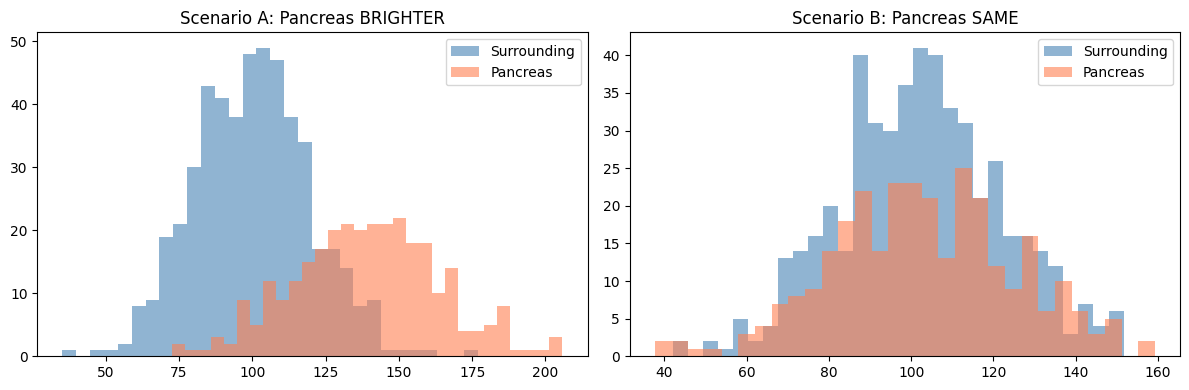

Feature           Scenario A   Scenario B
------------------------------------------
mean_diff             39.052        0.678
mean_ratio             1.390        1.007
std_diff               5.073        2.441
std_ratio              1.259        1.123
ks_statistic           0.647        0.067
p25_diff              36.419       -0.541
p75_diff              42.692        2.847

Scenario A shows large differences (pancreas is clearly brighter).
Scenario B shows near-zero differences (no contrast between regions).

In our real data (NB 23): all 11 contrast features ≈ Scenario B
→ The pancreas-surrounding relationship does not differ by rejection status.


In [9]:
# Demonstrate contrast features with two scenarios
np.random.seed(42)

# Scenario A: pancreas brighter than surrounding
surr_a = np.random.normal(100, 20, 500)
panc_a = np.random.normal(140, 25, 300)

# Scenario B: pancreas same as surrounding
surr_b = np.random.normal(100, 20, 500)
panc_b = np.random.normal(102, 22, 300)

def compute_contrast(panc_vals, surr_vals):
    feats = {}
    feats["mean_diff"] = np.mean(panc_vals) - np.mean(surr_vals)
    feats["mean_ratio"] = np.mean(panc_vals) / (np.mean(surr_vals) + 1e-8)
    feats["std_diff"] = np.std(panc_vals) - np.std(surr_vals)
    feats["std_ratio"] = np.std(panc_vals) / (np.std(surr_vals) + 1e-8)
    ks_stat, _ = stats.ks_2samp(panc_vals, surr_vals)
    feats["ks_statistic"] = ks_stat
    feats["p25_diff"] = np.percentile(panc_vals, 25) - np.percentile(surr_vals, 25)
    feats["p75_diff"] = np.percentile(panc_vals, 75) - np.percentile(surr_vals, 75)
    return feats


contrast_a = compute_contrast(panc_a, surr_a)
contrast_b = compute_contrast(panc_b, surr_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(surr_a, bins=30, alpha=0.6, color="steelblue", label="Surrounding")
axes[0].hist(panc_a, bins=30, alpha=0.6, color="coral", label="Pancreas")
axes[0].set_title("Scenario A: Pancreas BRIGHTER")
axes[0].legend()

axes[1].hist(surr_b, bins=30, alpha=0.6, color="steelblue", label="Surrounding")
axes[1].hist(panc_b, bins=30, alpha=0.6, color="coral", label="Pancreas")
axes[1].set_title("Scenario B: Pancreas SAME")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"{'Feature':<15} {'Scenario A':>12} {'Scenario B':>12}")
print("-" * 42)
for feat in contrast_a:
    print(f"{feat:<15} {contrast_a[feat]:>12.3f} {contrast_b[feat]:>12.3f}")

print("\nScenario A shows large differences (pancreas is clearly brighter).")
print("Scenario B shows near-zero differences (no contrast between regions).")
print("\nIn our real data (NB 23): all 11 contrast features ≈ Scenario B")
print("→ The pancreas-surrounding relationship does not differ by rejection status.")

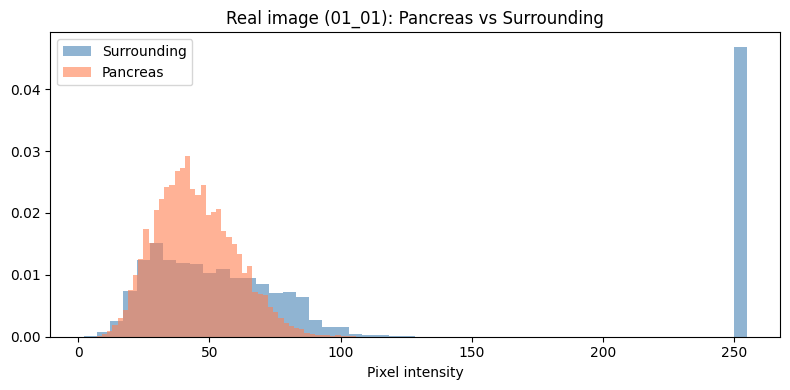

Contrast features for study 01_01:
  mean_diff      : -54.719
  mean_ratio     : 0.448
  std_diff       : -73.814
  std_ratio      : 0.170
  ks_statistic   : 0.345
  p25_diff       : -4.000
  p75_diff       : -46.000

Pancreas mean=44.5, Surrounding mean=99.2
The pancreas is darker than its surroundings by 54.7 intensity units.


In [10]:
# Real image contrast features
pancreas_vals = gray[mask > 0].astype(np.float64)
surround_vals = gray[surrounding > 0].astype(np.float64)

real_contrast = compute_contrast(pancreas_vals, surround_vals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(surround_vals, bins=50, alpha=0.6, color="steelblue", label="Surrounding", density=True)
ax.hist(pancreas_vals, bins=50, alpha=0.6, color="coral", label="Pancreas", density=True)
ax.set_title(f"Real image ({study_id}): Pancreas vs Surrounding")
ax.set_xlabel("Pixel intensity")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Contrast features for study {study_id}:")
for feat, val in real_contrast.items():
    print(f"  {feat:<15}: {val:.3f}")

print(f"\nPancreas mean={pancreas_vals.mean():.1f}, Surrounding mean={surround_vals.mean():.1f}")
print(f"The pancreas is {'brighter' if real_contrast['mean_diff'] > 0 else 'darker'} "
      f"than its surroundings by {abs(real_contrast['mean_diff']):.1f} intensity units.")

## Summary

| Concept | What it does | When it helps |
|---------|-------------|---------------|
| Z-score normalization | Removes global intensity offset/scale | First-order features (mean, median) |
| Surrounding mask | Provides local reference (not distant structures) | Better normalization baseline |
| Texture feature invariance | Ordinal features unchanged by linear transform | Explains why normalized ≈ original |
| Contrast features | Directly compares ROI to context | Novel information (not redundant) |

**Key takeaway:** Normalization is useful for first-order features and cross-image
comparability, but ordinal texture features (GLCM, GLRLM, etc.) are naturally
invariant to linear intensity shifts. The more informative approach for our question
("does surrounding context help predict rejection?") is contrast features — direct
comparison of pancreas vs surrounding — which turned out to be non-discriminative
in our dataset (all 11 features p > 0.1, ML AUC ≈ 0.5).